2026-01-04 00:10:28.738075: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-04 00:10:28.738518: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-04 00:10:28.741182: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-04 00:10:28.748120: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767496228.759644  290523 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767496228.76

Usando fashion como dataset


2026-01-04 00:10:31.048599: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "predictor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ original_input (InputLayer)     │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_layer (ReshapeLayer)    │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 14, 14, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 14, 14, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 7, 7, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 7, 7, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        31,370 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,570 (197.54 KB)

 Trainable params: 50,378 (196.79 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - loss: 0.5965 - val_loss: 0.5302
Epoch 2/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.4041 - val_loss: 0.3128
Epoch 3/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.3494 - val_loss: 0.2880
Epoch 4/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.3199 - val_loss: 0.2700
Epoch 5/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.2968 - val_loss: 0.2753
Epoch 6/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.2809 - val_loss: 0.2678
Epoch 7/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.2742 - val_loss: 0.2550
Epoch 8/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.2597 - val_loss: 0.2567
Epoch 9/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.2538 - val_loss: 0.2886
Epoch 10/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.2458 - val_loss: 0.2469
Epoch 11/1000
430/430 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.2382 - val_loss: 0.2733
Epoch 12/1000
430/4

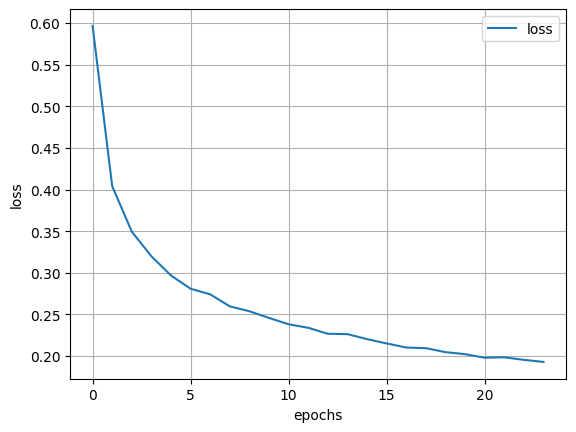

In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

import project.loader.load as load
from project.models_definitions import encoder
from project.models_definitions import decoder
from project.models_definitions import predictor
from project.models_definitions.cvae import CVAE 

import matplotlib.pyplot as plt

import tensorflow as tf
from keras.callbacks import EarlyStopping

## parametros
dataset="fashion"
data = load.data(dataset=dataset)
x_train = data["x_train"]
x_val = data["x_val"]
y_train = data["y_train"]
y_val = data["y_val"]
x_test = data["x_test"]
y_test = data["y_test"]

original_dim = 28*28
beta = 1.0

predictor = predictor.build_predictor()

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

predictor.compile(optimizer, loss="categorical_crossentropy")


early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = predictor.fit(
    x=x_train,
    y=y_train,
    epochs=1000,
    batch_size=128,
    validation_data=(x_val, y_val),
    callbacks=[early_stopping],
    verbose=1)

predictor.save("early_stop_fashion.keras")
plt.plot(history.history["loss"], label="loss")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.grid()
plt.legend()
#plt.savefig(f"loss_vs_epochs_model_int_{intermediate_dim[i]}_lat_{latent_dim[i]}_{dataset}")
plt.show()

modelo entrando recien

In [22]:
import numpy as np

dataset="fashion"
data = load.data(dataset=dataset)
x_train = data["x_train"]
x_val = data["x_val"]
y_train = data["y_train"]
y_val = data["y_val"]
x_test = data["x_test"]
y_test = data["y_test"]

# predicciones
y_pred = predictor.predict(x_test)

# convertir one-hot a etiquetas
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

# accuracy manual
accuracy = np.mean(y_pred_labels == y_true_labels)

print(f"Test accuracy (manual): {accuracy:.4f}")


Usando fashion como dataset
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Test accuracy (manual): 0.9176


modelo entrenado antes

In [3]:
import numpy as np
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

import project.loader.load as load
from project.models_definitions import encoder
from project.models_definitions import decoder
from project.models_definitions import predictor
from project.models_definitions.cvae import CVAE 

import matplotlib.pyplot as plt

import tensorflow as tf
from keras.callbacks import EarlyStopping

dataset="fashion"
data = load.data(dataset=dataset)
x_train = data["x_train"]
x_val = data["x_val"]
y_train = data["y_train"]
y_val = data["y_val"]
x_test = data["x_test"]
y_test = data["y_test"]

predictor_viejo = load.predictor(dataset=dataset)


# predicciones
y_pred = predictor_viejo.predict(x_test)

# convertir one-hot a etiquetas
y_pred_labels = np.argmax(y_pred, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

# accuracy manual
accuracy = np.mean(y_pred_labels == y_true_labels)

print(f"Test accuracy (manual): {accuracy:.4f}")


Usando fashion como dataset
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Test accuracy (manual): 0.8965


# Predictor a secas


In [ ]:
import os
import random
import numpy as np
import tensorflow as tf
import sys

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from project.loader import Loader

SEED = 1234
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

dataset = "mnist"


data = Loader.data(dataset=dataset)
predictor = Loader.predictor(dataset=dataset)

x_test = data["x_test"]
x_test_1 = data["x_test_1"]
y_test = data["y_test"]
y_test_1 = data["y_test_1"]

def to_class_indices(y):
    y = np.asarray(y)
    if y.ndim > 1 and y.shape[1] > 1:
        return np.argmax(y, axis=1)
    return y.reshape(-1)

def top2_pair_accuracy(predictor, x1, x2, y1, y2, alpha_mix=0.5):
    x1 = x1.astype(np.float32)
    x2 = x2.astype(np.float32)

    mixed = alpha_mix * x1 + (1.0 - alpha_mix) * x2
    probs = predictor(mixed, training=False).numpy()

    top2_idx = np.argsort(probs, axis=1)[:, -2:]
    top2_idx = top2_idx[:, ::-1]  # mejor, segundo mejor

    top2_probs = np.take_along_axis(probs, top2_idx, axis=1)

    y1_idx = to_class_indices(y1)
    y2_idx = to_class_indices(y2)

    both_correct = []
    for i, (label1, label2) in enumerate(zip(y1_idx, y2_idx)):
        top2_set = set(top2_idx[i].tolist())
        both_correct.append((label1 in top2_set) and (label2 in top2_set))

    accuracy_both = np.mean(both_correct)

    return {
        "accuracy_both": accuracy_both,
        "top2_indices": top2_idx,
        "top2_probs": top2_probs,
        "both_correct": np.array(both_correct, dtype=np.bool_),
    }

n_images = 1000

results = top2_pair_accuracy(
    predictor,
    x_test[:n_images],
    x_test_1[:n_images],
    y_test[:n_images],
    y_test_1[:n_images],
)

print("Top-2 accuracy para identificar ambas clases:", results["accuracy_both"])
print("Top-2 índices por imagen:\n", results["top2_indices"])


Usando mnist como dataset
Top-2 accuracy para identificar ambas clases: 0.541
Top-2 índices por imagen:
 [[7 2]
 [0 2]
 [6 1]
 ...
 [0 3]
 [8 9]
 [9 8]]
Top-2 probabilidades por imagen:
 [[7.3497838e-01 2.6424825e-01]
 [9.0871501e-01 9.1077551e-02]
 [9.2519253e-01 2.8678887e-02]
 ...
 [9.0671772e-01 5.6619726e-02]
 [9.9984741e-01 9.6903896e-05]
 [5.4584426e-01 2.9587439e-01]]


/home/galsan/Desktop/tesis/CROP_1/.venv/lib/python3.11/site-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['original_input']
Received: inputs=Tensor(shape=(1000, 784))
  warnings.warn(msg)


In [ ]:
n_images=10
y1_idx = to_class_indices(y_test[:n_images])
y2_idx = to_class_indices(y_test_1[:n_images])

mixed = 0.5 *   x_test[:n_images] + (1.0 - 0.5) *   x_test_1[:n_images]

predictor = Loader.predictor(dataset=dataset)

probs = np.argsort(predictor.predict(mixed))
print("probs ",probs)
print("y1_indx ",y1_idx)
print("y2_indx ", y2_idx)






1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
probs  [[6 5 4 9 1 0 8 3 2 7]
 [5 7 4 9 3 8 1 6 2 0]
 [9 7 2 0 3 5 8 4 1 6]
 [7 4 1 5 9 3 2 6 8 0]
 [2 1 0 5 6 3 7 8 4 9]
 [0 6 5 4 9 7 2 3 1 8]
 [5 0 6 7 3 1 9 4 2 8]
 [7 3 5 0 2 4 1 6 9 8]
 [4 7 1 6 2 0 9 8 5 3]
 [5 1 6 4 3 2 7 0 9 8]]
y1_indx  [7 2 1 0 4 1 4 9 5 9]
y2_indx  [2 0 6 8 9 8 2 6 3 2]


In [43]:
import numpy as np

def compute_top2_pair_accuracy_from_sorted_indices(sorted_indices, y1_idx, y2_idx):
    # sorted_indices ya es el orden de clases de menor a mayor
    top2 = sorted_indices[:, -2:]
    correct = []
    for a, b, top2_row in zip(y1_idx, y2_idx, top2):
        s = set(top2_row.tolist())
        correct.append((a in s) and (b in s))
    return np.mean(correct), np.array(correct, dtype=np.bool_), top2

dataset = "fashion"

data = Loader.data(dataset=dataset)
predictor = Loader.predictor(dataset=dataset)

x_test = data["x_test"]
x_test_1 = data["x_test_1"]
y_test = data["y_test"]
y_test_1 = data["y_test_1"]

n_images = -1
mixed = 0.5 * x_test[:n_images] + 0.5 * x_test_1[:n_images]

predictions = predictor.predict(mixed)          # shape (n_images, n_classes)
sorted_indices = np.argsort(predictions, axis=1)  # cada fila ordena clases de menor a mayor

y1_idx = to_class_indices(y_test[:n_images])
y2_idx = to_class_indices(y_test_1[:n_images])

accuracy, correct_mask, top2 = compute_top2_pair_accuracy_from_sorted_indices(
    sorted_indices, y1_idx, y2_idx
)

print("Top-2 indices por fila:\n", top2)
print("Acierto por caso:", correct_mask.astype(int))
print("Precisión:", accuracy)

Usando fashion como dataset
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Top-2 indices por fila:
 [[9 1]
 [6 2]
 [4 1]
 ...
 [1 3]
 [0 6]
 [4 1]]
Acierto por caso: [1 0 1 ... 1 0 0]
Precisión: 0.41184118411841186


2026-04-27 17:26:13.120908: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-27 17:26:13.121368: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-27 17:26:13.124025: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-27 17:26:13.130991: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777321573.143080 3538758 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777321573.14

Usando fashion como dataset


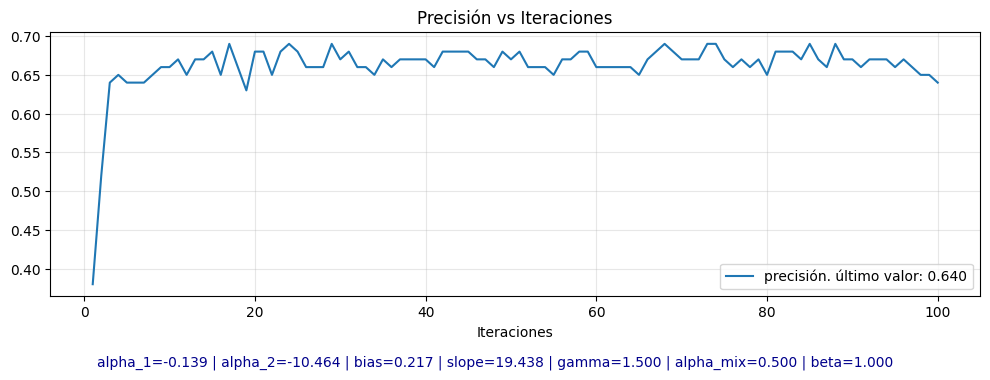

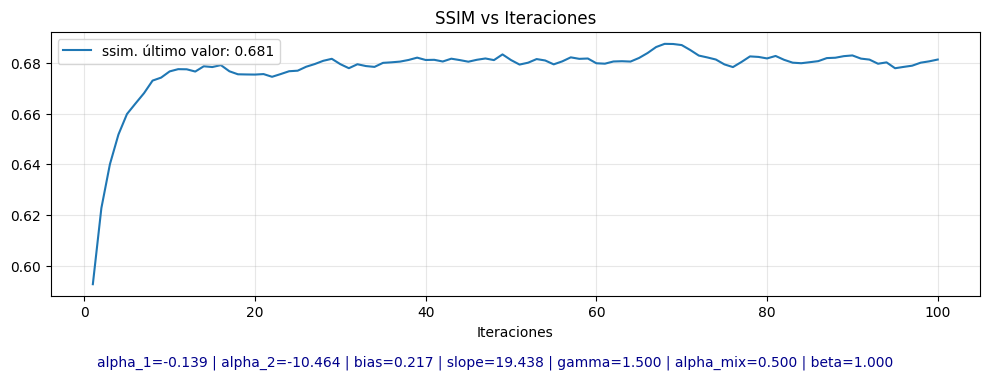

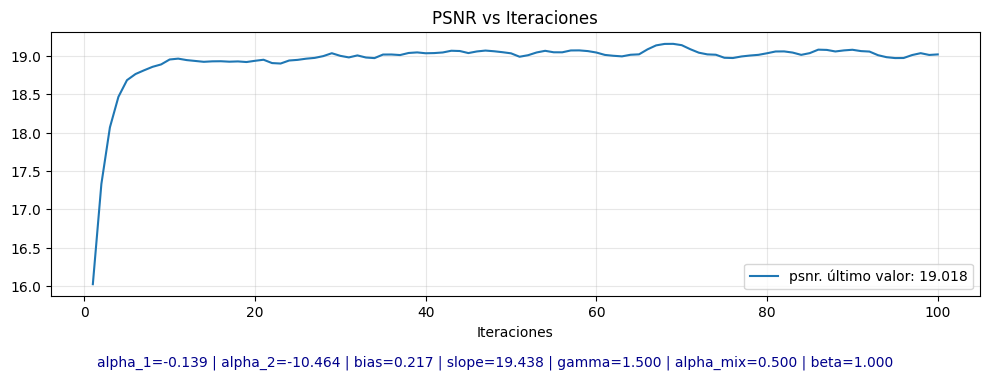


======= PARÁMETROS DEL MODELO =====================
alpha_1   : -0.139
alpha_2   : -10.464
bias      : 0.217
slope     : 19.438
gamma     : 1.500
alpha_mix : 0.500
beta      : 1.000

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 19.018  std:3.154
mask_bpsnr       : mean: 11.789  std:1.832
ssim             : mean: 0.681  std:0.148
acc_at_least_one : 0.970
acc_both         : 0.640



In [1]:

import os
import random
import numpy as np
import tensorflow as tf
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from project.loader import Loader
from project.CROP.models.crop_base_model import CropBaseModel
from project.custom_layers.sampling import Sampling
import tensorflow as tf


from project.CROP.models.crop2 import Crop2

SEED = 1234 #Semilla
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


ITERATIONS = 100
N_PICTURES = 100

DATASET = "fashion" # minst o fashion
LAT = 128
INTER = 256
cvae = Loader.cvae(inter=INTER,lat=LAT,dataset=DATASET)
data = Loader.data(dataset=DATASET)

predictor = Loader.predictor(dataset=DATASET)

x_test = data["x_test"]
x_test_1 = data["x_test_1"]
y_test = data["y_test"]
y_test_1 = data["y_test_1"]
labels= data["labels"]

c = Crop2(cvae=cvae,predictor=predictor)

acc_both_params={'bias': 0.21716868437244724,
'slope': 19.437646607877017,
 'alpha_1': -0.13863158439804657,
  'alpha_2': -10.463749682840565,
  #'gamma': 0.3,
  #'gamma': 0.84,
  'gamma': 1.5,
  }


metrics = c.unmix(
    x_test[:N_PICTURES],
    x_test_1[:N_PICTURES],
    y_test[:N_PICTURES],
    y_test_1[:N_PICTURES],
    iterations=ITERATIONS,
    show_image=False,
    labels=labels,
    params=acc_both_params,
    show_all_curves=True
    )


In [ ]:
#optim + sepración
import os
import random
import numpy as np
import tensorflow as tf
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

SEED = 1234

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

from project.loader import Loader
from project.CROP.models.crop3 import Crop3

dataset = "fashion"

lat=64
inter=256
data = Loader.data(dataset=dataset)
predictor = Loader.predictor(dataset=dataset)

x_test = data["x_test"]
x_test_1 = data["x_test_1"]
y_test = data["y_test"]
y_test_1 = data["y_test_1"]


c = Crop3(predictor=predictor,lat=lat,inter=inter,dataset=dataset)

def objective(trial):
#
    #bias = trial.suggest_float("bias", 0.05,0.30)
    #slope = trial.suggest_float("slope", 5,20 )
    #gamma = trial.suggest_float("gamma", 0.1, 0.45)
    #alpha_1= trial.suggest_float("alpha_1", -0.3, -0.05)
    #alpha_2= trial.suggest_float("alpha_2", -30, -5)
# beta = trial.suggest_float("beta",0,1.5)
#####
    bias_e = trial.suggest_float("bias", -1,10)
    slope_e = trial.suggest_float("slope", -0.1,25 )
    gamma = trial.suggest_float("gamma", 0,3 )
    
    n_images=2000
    try:
        metrics = c.unmix(
            x_test[:n_images],
            x_test_1[:n_images],
            y_test[:n_images],
            y_test_1[:n_images],
            params={'bias': 0.21716868437244724,
            'slope': 19.437646607877017,
            'alpha_1': -0.13863158439804657,
            'alpha_2': -10.463749682840565,
            "gamma": gamma,
            "bias_e":bias_e,
            "slope_e":slope_e},                
            iterations=10,
            show_metrics=False
        )
        ssim_mean = float(metrics["ssim"][0])
        recon_bpsnr_mean = float(metrics["recon_bpsnr"][0])
        return ssim_mean, recon_bpsnr_mean

    except Exception as e:
        print(f"Error con gamma={gamma}: {e}")
        return float("-inf"), float("-inf")


import optuna


study = optuna.create_study(directions=["maximize", "maximize"])
study.optimize(objective, n_trials=100)

# Mostramos los mejores resultados
print("\n📊 Mejores hiperparámetros encontrados:")
print(study.best_trials[0].params)
print("Valores objetivo:", study.best_trials[0].values)

#{'gamma': 1.378449424990954} psnr 
#'gamma': 0.11498749766563751

2026-04-22 02:12:32.258144: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-22 02:12:32.258615: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-22 02:12:32.261606: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-22 02:12:32.269126: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776834752.281036 2938956 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776834752.28

Usando fashion como dataset


2026-04-22 02:12:35.147755: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
/home/galsan/Desktop/tesis/CROP_1/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-04-22 02:12:35,338] A new study created in memory with name: no-name-f9181e81-76ba-4fd7-8c9d-a58a34ffe959
[I 2026-04-22 02:12:38,020] Trial 0 finished with values: [0.3965590298175812, 15.731244087219238] and parameters: {'bias': 0.504592870050518, 'slope': 15.219638483618276, 'gamma': 0.8455709829523271}.
[I 2026-04-22 02:12:40,818] Trial 1 finished with values: [0.399624764919281, 15.193432807922363] and parameters: {'bias': 3.7338847142407765, 'slope': 23.320237257561455, 'gamma': 2.7181136205863683}.
[I 2026-04-22 02:12:43,48


📊 Mejores hiperparámetros encontrados:
{'bias': 0.504592870050518, 'slope': 15.219638483618276, 'gamma': 0.8455709829523271}
Valores objetivo: [0.3965590298175812, 15.731244087219238]
